In [2]:
import pandas as pd
import numpy as np

# Назви колонок
headers = ["symboling", "normalized-losses", "make", "fuel-type", "aspiration",
           "num-of-doors", "body-style", "drive-wheels", "engine-location",
           "wheel-base", "length", "width", "height", "curb-weight", "engine-type",
           "num-of-cylinders", "engine-size", "fuel-system", "bore", "stroke",
           "compression-ratio", "horsepower", "peak-rpm", "city-mpg", "highway-mpg", "price"]

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data"
df = pd.read_csv(url, names=headers, na_values="?")

print("Пропущені значення ДО очищення:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Пропущені значення ДО очищення:
normalized-losses    41
num-of-doors          2
bore                  4
stroke                4
horsepower            2
peak-rpm              2
price                 4
dtype: int64


In [3]:
# 1. Видаляємо рядки, де немає ціни
df.dropna(subset=['price'], axis=0, inplace=True)

# Оскільки ми видалили рядки, потрібно скинути індекси
df.reset_index(drop=True, inplace=True)

# 2. Заповнюємо числові колонки середнім значенням
numeric_cols = ['normalized-losses', 'bore', 'stroke', 'horsepower', 'peak-rpm']
for col in numeric_cols:
    # Перетворюємо колонку на числовий тип (на випадок, якщо вона зчиталась як текст)
    df[col] = df[col].astype(float)
    # Рахуємо середнє і заповнюємо ним пропуски
    mean_val = df[col].mean()
    df[col] = df[col].fillna(mean_val)

# 3. Заповнюємо категоріальну колонку 'num-of-doors' найчастішим значенням (модою)
most_frequent_doors = df['num-of-doors'].value_counts().idxmax()
df['num-of-doors'] = df['num-of-doors'].fillna(most_frequent_doors)

# Перевіряємо результат
print("\nПропущені значення ПІСЛЯ очищення (має бути пусто):")
print(df.isnull().sum()[df.isnull().sum() > 0])

# Конвертуємо 'price' у числовий тип для майбутніх графіків
df['price'] = df['price'].astype(float)


Пропущені значення ПІСЛЯ очищення (має бути пусто):
Series([], dtype: int64)


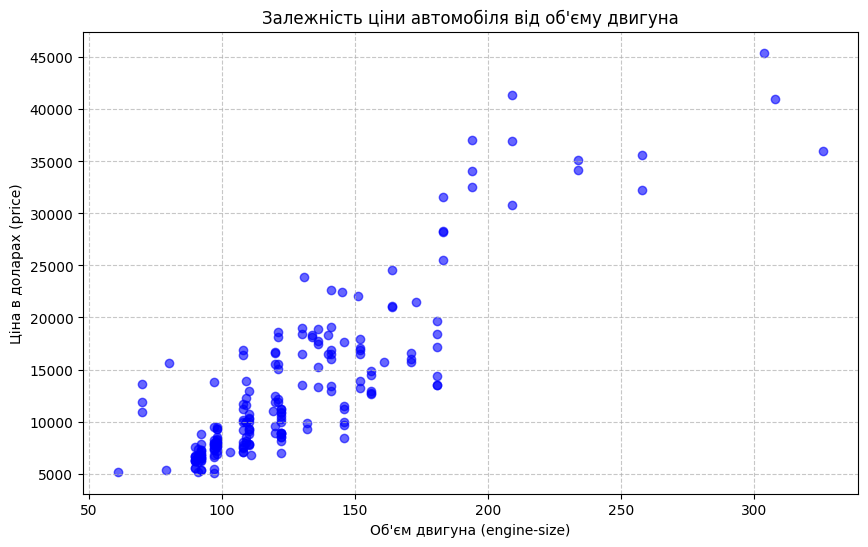

In [4]:
import matplotlib.pyplot as plt

# Задаємо розмір графіка
plt.figure(figsize=(10, 6))

# Будуємо точкову діаграму (scatter plot)
plt.scatter(df['engine-size'], df['price'], alpha=0.6, color='blue')

# Додаємо підписи
plt.title("Залежність ціни автомобіля від об'єму двигуна")
plt.xlabel("Об'єм двигуна (engine-size)")
plt.ylabel("Ціна в доларах (price)")
plt.grid(True, linestyle='--', alpha=0.7)

# Показуємо графік
plt.show()

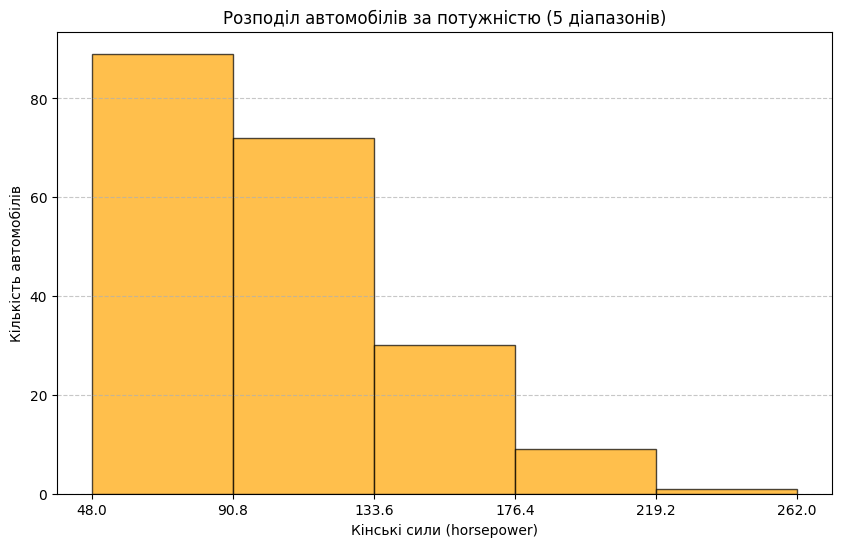

Межі 5 діапазонів: [ 48.   90.8 133.6 176.4 219.2 262. ]


In [5]:
plt.figure(figsize=(10, 6))

# Будуємо гістограму, вказуючи рівно 5 діапазонів (bins=5)
counts, bins, patches = plt.hist(df['horsepower'], bins=5, edgecolor='black', color='orange', alpha=0.7)

# Додаємо підписи
plt.title("Розподіл автомобілів за потужністю (5 діапазонів)")
plt.xlabel("Кінські сили (horsepower)")
plt.ylabel("Кількість автомобілів")

# Щоб точно бачити межі цих 5 діапазонів на осі X
plt.xticks(bins)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

# Виведемо межі діапазонів текстом для звіту
print(f"Межі 5 діапазонів: {bins}")

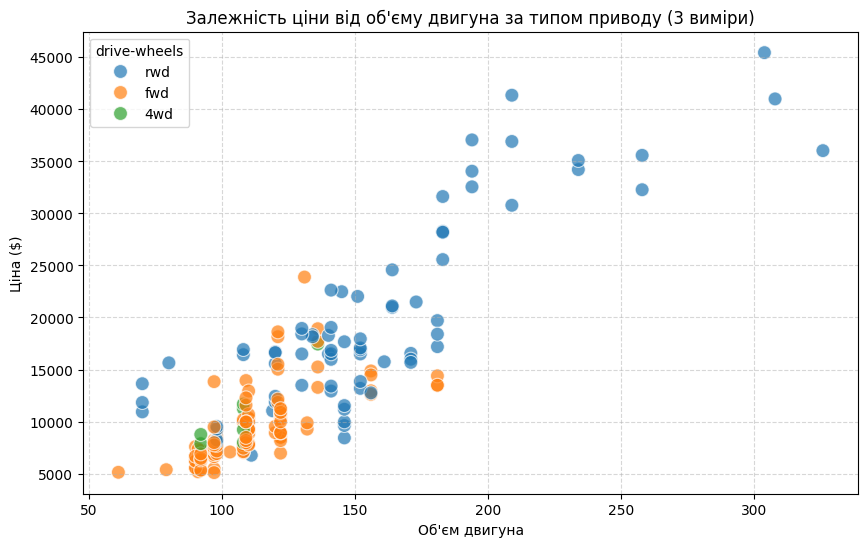

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# hue='drive-wheels' додає третій вимір (колір)
sns.scatterplot(data=df, x='engine-size', y='price', hue='drive-wheels', s=100, alpha=0.7)

plt.title("Залежність ціни від об'єму двигуна за типом приводу (3 виміри)")
plt.xlabel("Об'єм двигуна")
plt.ylabel("Ціна ($)")
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

C:\Users\User\AppData\Local\Temp\ipykernel_23724\4286645881.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='body-style', y='price', palette='Set2')


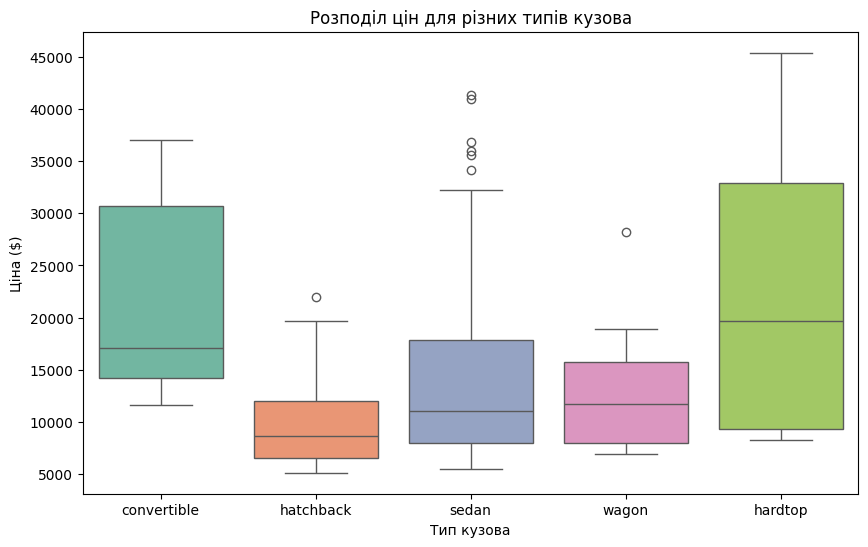

In [8]:
plt.figure(figsize=(10, 6))

# Будуємо Boxplot
sns.boxplot(data=df, x='body-style', y='price', palette='Set2')

plt.title("Розподіл цін для різних типів кузова")
plt.xlabel("Тип кузова")
plt.ylabel("Ціна ($)")

plt.show()

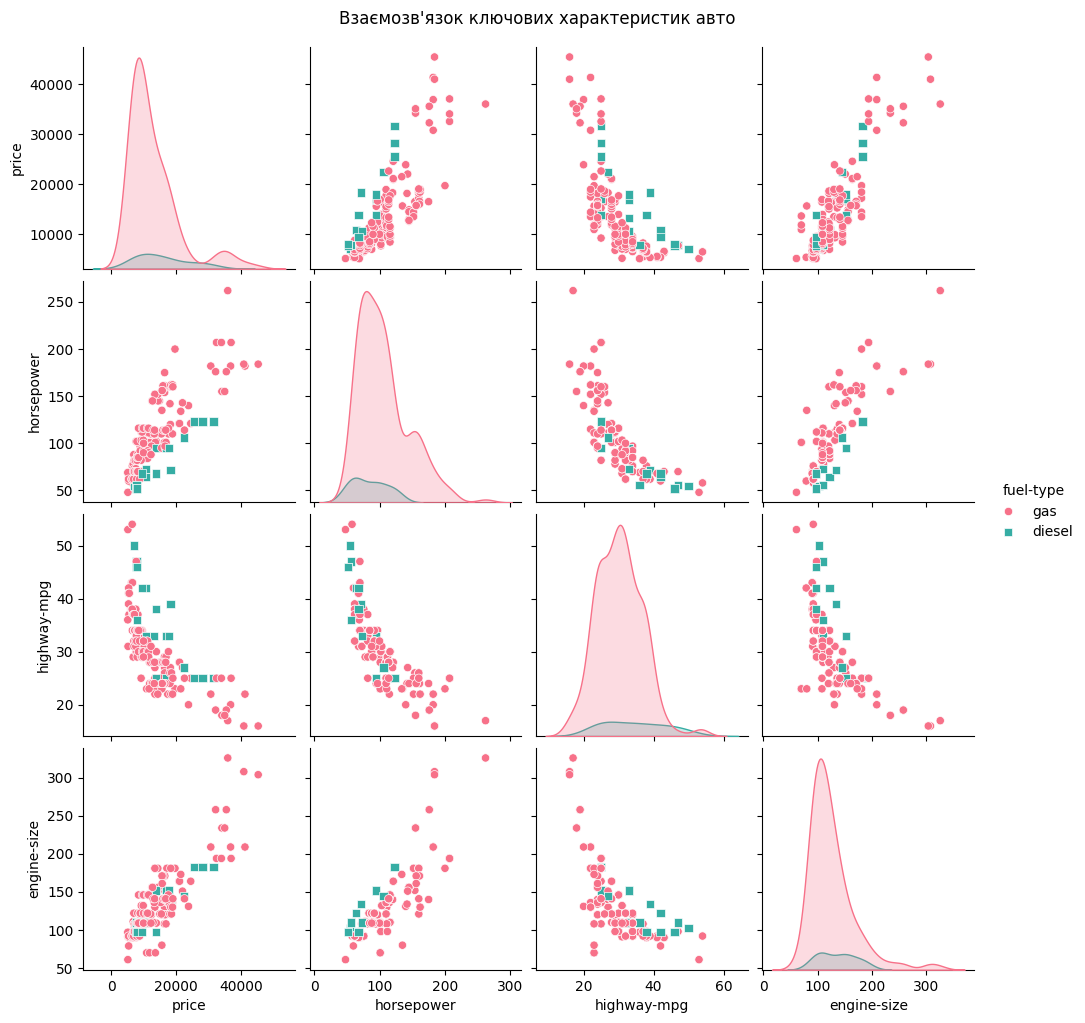

In [9]:
# Обираємо лише кілька найцікавіших колонок, щоб графік не був занадто великим
cols_to_plot = ['price', 'horsepower', 'highway-mpg', 'engine-size', 'fuel-type']

# Будуємо pairplot, розфарбовуючи за типом пального (fuel-type: gas/diesel)
sns.pairplot(df[cols_to_plot], hue='fuel-type', palette='husl', markers=["o", "s"])

# Заголовок додається трохи інакше для сітки графіків
plt.suptitle("Взаємозв'язок ключових характеристик авто", y=1.02)
plt.show()

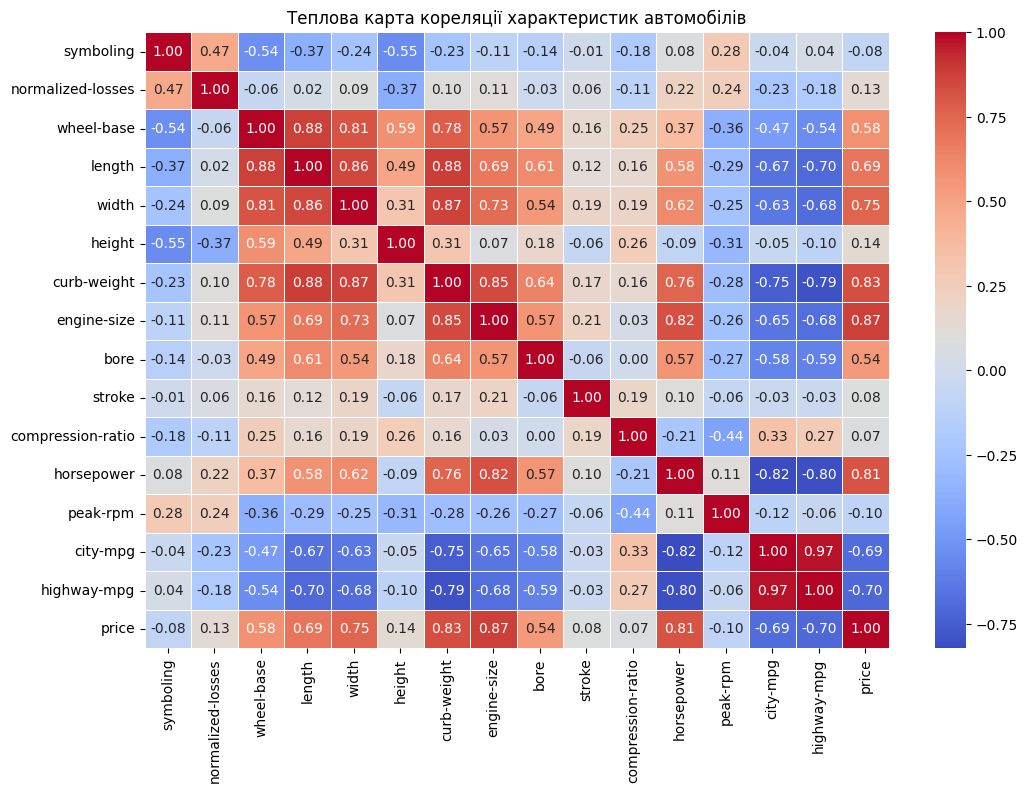

In [10]:
plt.figure(figsize=(12, 8))

# Обираємо тільки числові колонки для розрахунку кореляції
numeric_df = df.select_dtypes(include=['float64', 'int64'])

# Розраховуємо матрицю кореляції та будуємо теплову карту
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)

plt.title("Теплова карта кореляції характеристик автомобілів")
plt.show()